# Vergleich der 6 DPO-Modell-Konfigurationen auf dem Lebenshilfe-Datensatz

Dieses Notebook lädt alle 6 trainierten DPO-Modelle und evaluiert sie auf demselben Lebenshilfe-Datensatz. So können wir direkt vergleichen:
1. **Trainer vs. Nicht-Trainer** (Exakte Log-Wahrscheinlichkeiten vs. Durchschnittlicher Loss)
2. **Reward-Gewichtung** ($w_{\\text{style}}=0.5, w_{\\text{sem}}=0.5$ vs. $w_{\\text{style}}=1.0, w_{\\text{sem}}=0.0$)
3. **Trainings-Datensatz** (Normal/Final vs. Enriched)

In [ ]:
import os
import sys
import json
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer
from IPython.display import display

LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset.json"
SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"
SBERT_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

MODELS_TO_COMPARE = {
    "SFT (Base Model)": "results/models/sft",
    "DPO 1 (Loss, w_style=0.5, w_sem=0.5)": "results/models/dpo_w_style_0.5_w_sem_0.5",
    "DPO 2 (Loss, w_style=1.0, w_sem=0.0)": "results/models/dpo_w_style_1.0_w_sem_0.0",
    "DPO 3 (Loss, w_style=0.0, w_sem=1.0)": "results/models/dpo_w_style_0.0_w_sem_1.0",
    "DPO Trainer 1 (w_style=0.5, w_sem=0.5)": "results/models/dpo_trainer_w_style_0.5_w_sem_0.5",
    "DPO Trainer 2 (w_style=1.0, w_sem=0.0)": "results/models/dpo_trainer_w_style_1.0_w_sem_0.0",
    "DPO Trainer 3 (w_style=0.0, w_sem=1.0)": "results/models/dpo_trainer_w_style_0.0_w_sem_1.0",
}

## 1. Simplicity- & SBERT-Modelle laden

In [4]:
# Load Simplicity Model
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

with open(SYNTHETIC_VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
    synthetic_stoi = vocab_data.get("stoi", vocab_data)

bilstm_model = BiLSTMRegressor(len(synthetic_stoi), embed_dim=128, hidden_dim=128)
if os.path.exists(SYNTHETIC_MODEL_PATH):
    bilstm_model.load_state_dict(torch.load(SYNTHETIC_MODEL_PATH, map_location="cpu"))
    bilstm_model.to("cpu")
    bilstm_model.eval()
    print(f"BiLSTM Synthetic Regressor geladen von {SYNTHETIC_MODEL_PATH}")
else:
    print(f"Warnung: {SYNTHETIC_MODEL_PATH} nicht gefunden.")

nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])

def predict_simplicity_score(texts):
    scores = []
    unk_idx = synthetic_stoi.get("<unk>") or synthetic_stoi.get("<UNK>") or 1
    for text in texts:
        doc = nlp(text)
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [synthetic_stoi.get(t, unk_idx) for t in tokens[:150]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device="cpu")
        with torch.no_grad():
            score = bilstm_model(inp_tensor).item()
        scores.append(score)
    return np.array(scores)


BiLSTM Synthetic Regressor geladen von results/models/bilstm_synthetic_regression.pt


In [5]:
# Load SBERT Model
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device="cpu")

def predict_semantic_similarity(source_texts, generated_texts):
    emb_src = sbert_model.encode(source_texts, convert_to_tensor=True)
    emb_gen = sbert_model.encode(generated_texts, convert_to_tensor=True)
    cosine_sims = util.cos_sim(emb_src, emb_gen).diagonal().cpu().numpy()
    return cosine_sims

class CompositeRewardEvaluator:
    def __init__(self, w_style=0.5, w_sem=0.5):
        self.w_style = w_style
        self.w_sem = w_sem
        
    def compute_reward(self, source_texts, generated_texts):
        r_style = predict_simplicity_score(generated_texts)
        r_sem = predict_semantic_similarity(source_texts, generated_texts)
        r_sem_norm = np.clip((r_sem + 1.0) / 2.0, 0.0, 1.0)
        total_reward = self.w_style * r_style + self.w_sem * r_sem_norm
        return total_reward, r_style, r_sem_norm

# Standardisierte Evaluierung (w_style=0.5, w_sem=0.5) für alle Vergleiche
reward_evaluator = CompositeRewardEvaluator(w_style=0.5, w_sem=0.5)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## 2. Lebenshilfe-Datensatz laden & Evaluierungsfunktion definieren

In [6]:
# Lebenshilfe-Datensatz laden
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)
print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")


Lebenshilfe Datensatz geladen: 49 Artikel-Paare.


In [7]:
# Evaluierungs-Funktion
def evaluate_model(model_path, lh_data, max_samples=49):
    if not os.path.exists(model_path):
        print(f"Warnung: Modell-Pfad {model_path} existiert nicht. Überspringe.")
        return None, None
        
    print(f"Lade Modell von: {model_path}...")
    tokenizer = MBart50TokenizerFast.from_pretrained(model_path)
    model = MBartForConditionalGeneration.from_pretrained(model_path).to(DEVICE)
    model.eval()
    
    as_texts = [item["as_text"] for item in lh_data[:max_samples]]
    ls_ref_texts = [item["ls_text"] for item in lh_data[:max_samples]]
    
    batch_size = 16
    gen_texts = []
    for i in range(0, len(as_texts), batch_size):
        batch_src = as_texts[i:i+batch_size]
        prompts = ["Übersetze in Leichte Sprache: " + t for t in batch_src]
        inputs = tokenizer(prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_length=MAX_TARGET_LEN,
                num_beams=4,
                repetition_penalty=1.2,
                no_repeat_ngram_size=3,
                early_stopping=True
            )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        gen_texts.extend(decoded)
        
    tot_reward, r_style, r_sem = reward_evaluator.compute_reward(as_texts, gen_texts)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, gen_texts)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    # Speicher freigeben
    del model, tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    summary = {
        "r_style": r_style.mean(),
        "r_sem_as": r_sem.mean(),
        "sim_ref": sim_to_ref_norm.mean(),
        "reward": tot_reward.mean()
    }
    
    details = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "translation": gen_texts,
        "r_style": r_style,
        "r_sem_as": r_sem,
        "sim_ref": sim_to_ref_norm,
        "reward": tot_reward
    })
    
    return summary, details


## 3. Modelle evaluieren

In [8]:
# Modelle evaluieren
results_summary = {}
results_details = {}

for name, path in MODELS_TO_COMPARE.items():
    summary, details = evaluate_model(path, lh_data, max_samples=MAX_SAMPLES)
    if summary is not None:
        results_summary[name] = summary
        results_details[name] = details


Lade Modell von: results/models/seq2seq_dpo_w05_w05_final...


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

Lade Modell von: results/models/seq2seq_dpo_w05_w05_final_trainer...


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

Lade Modell von: results/models/seq2seq_dpo_w10_w00_final...


...

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

Lade Modell von: results/models/seq2seq_dpo_w05_w05_enriched...


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

Lade Modell von: results/models/seq2seq_dpo_w05_w05_enriched_trainer...


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

## 4. Übersichtstabelle

In [9]:
# Übersichtstabelle erstellen
df_summary = pd.DataFrame(results_summary).T
df_summary.columns = [
    "Ø Simplicity (R_style)",
    "Ø Sem-Sim to AS (R_sem)",
    "Ø Sem-Sim to LS Reference",
    "Ø Composite Reward (0.5/0.5)"
]
print("=== VERGLEICHSTABELLE ALLER DPO-MODELLE ===")
display(df_summary.round(4))


=== VERGLEICHSTABELLE ALLER DPO-MODELLE ===


,Ø Simplicity (R_style),Ø Sem-Sim to AS (R_sem),Ø Sem-Sim to LS Reference,Ø Composite Reward (0.5/0.5)
1_dpo_w05_w05_final (Non-Trainer),0.8422,0.8733,0.8334,0.8577
1_dpo_w05_w05_final_trainer (Trainer),0.7491,0.8867,0.8418,0.8179
2_dpo_w10_w00_final (Non-Trainer),0.9345,0.8689,0.8383,0.9017
2_dpo_w10_w00_final_trainer (Trainer),0.6182,0.8938,0.8401,0.7560
3_dpo_w05_w05_enriched (Non-Trainer),0.7769,0.9058,0.8551,0.8413
3_dpo_w05_w05_enriched_trainer (Trainer),0.7774,0.8920,0.8370,0.8347


## 5. Visualisierung

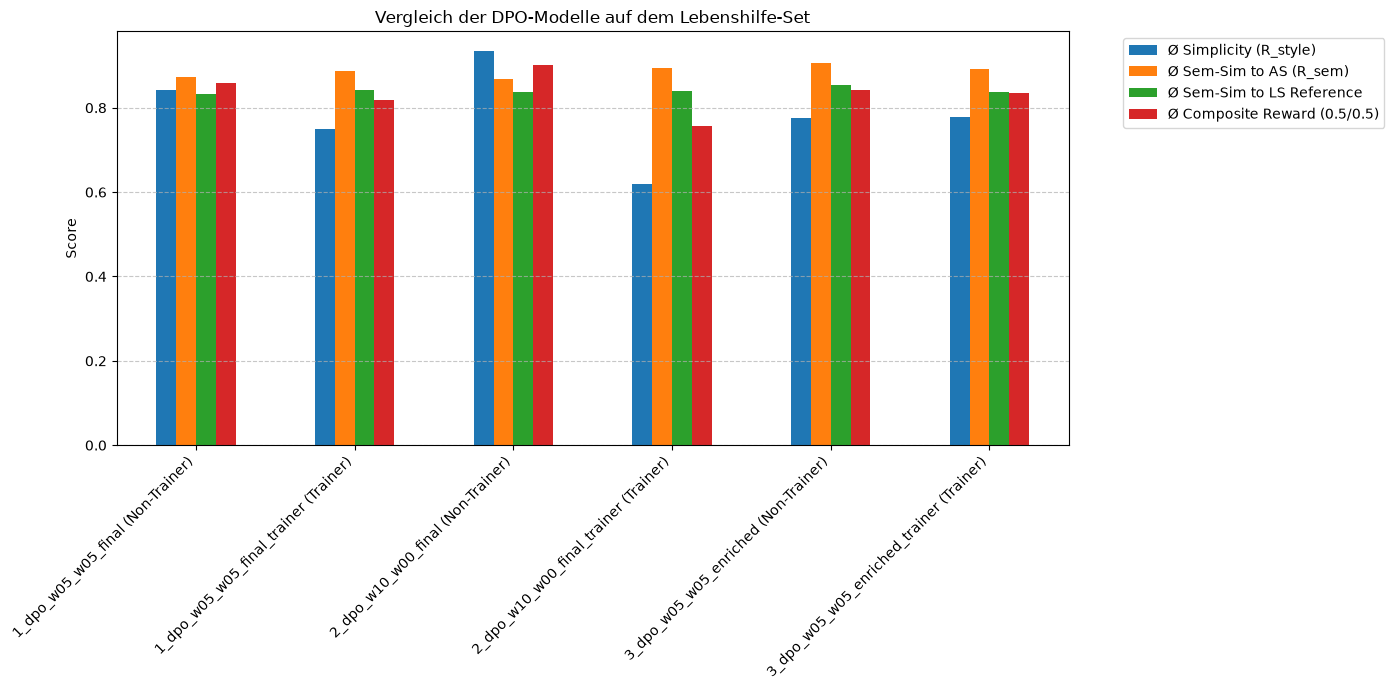

In [10]:
# Visualisierung
if not df_summary.empty:
    df_summary.plot(kind="bar", figsize=(14, 7))
    plt.title("Vergleich der DPO-Modelle auf dem Lebenshilfe-Set")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## 6. Qualitative Stichproben

In [11]:
# Qualitative Stichproben
if results_details:
    sample_df = pd.DataFrame({
        "AS (Quelle)": [item["as_text"] for item in lh_data[:3]],
        "LS (Referenz)": [item["ls_text"] for item in lh_data[:3]]
    })
    for name in results_details.keys():
        sample_df[name] = results_details[name]["translation"].head(3).values
        
    pd.set_option("display.max_colwidth", None)
    print("=== QUALITATIVE STICHPROBEN IM VERGLEICH ===")
    display(sample_df)


=== QUALITATIVE STICHPROBEN IM VERGLEICH ===


AS (Quelle)  \
0  Presseinformation von CAU und StK\n3.12.2024\nxxx/2024\n„Inklusion im Fokus“: Aktionstag an der CAU bringt alle zusammen\n\nMinisterpräsident Daniel Günther eröffnet Veranstaltung mit Filmpremiere „Das ist Leben - einzigartig vielfältig“\n\nDer 3. Dezember ist der internationale Tag der Menschen mit Behinderungen. Zu diesem Anlass hatte die Christian-Albrechts-Universität zu Kiel (CAU) gemeinsam mit der Landesregierung zum Aktionstag „Inklusion im Fokus“ im Kieler Wissenschaftszentrum eingeladen. Über 100 Gäste aus Bildung, Hochschulen und Politik kamen, um über Inklusion und Teilhabe zu diskutieren.\n\nMinisterpräsident Daniel Günther sagte zur Begrüßung: „Gelebte Inklusion ist die Voraussetzung für eine vielfältige, gleichberechtigte Gesellschaft. Die Landesregierung hat in diesem Bereich schon viel auf den Weg gebracht. Aber Inklusionsprozesse benötigen Zeit, und es gibt noch viel zu tun. Umso mehr freue ich mich über den Film, der anschaulich über dieses wichtige Thema informiert. Unser gemeinsames Ziel ist, Inklusion und Teilhabe aller Menschen in Schleswig-Holstein nachhaltig zu stärken.“\n\nDer knapp 30-minütige Film „Das ist Leben - einzigartig vielfältig“, in Auftrag gegeben von der Landesregierung, begleitet drei Menschen mit Behinderungen aus Schleswig-Holstein in ihrem Alltag. Die Paralympics-Siegerin Tanja Scholz, Pauline Schewerdin und Jorge Schönherr geben Einblicke in ihre Lebenswelt. Es wird gezeigt, welchen Schwierigkeiten sie täglich gegenüberstehen, aber auch, wie eine inklusive Gesellschaft funktionieren kann.\n\nIn einem Praxisseminar hatten Studierende und Bildungsfachkräfte des Instituts für inklusive Bildung (IIB) an der CAU in inklusiver Zusammenarbeit außerdem Begleitmaterialien zu dem Dokumentarfilm entwickelt. Auf dem Podium berichteten sie von ihren Erfahrungen. Sowohl der Film als auch die ergänzenden Materialien stehen Bildungseinrichtungen und anderen Interessierten künftig kostenfrei online zur Verfügung. \n\n„Inklusion als Prozess, der soziale Rollen neu verteilt“\n\nIm Anschluss an die Filmpremiere trafen Podiumsgäste aus Bildung und Politik aufeinander, um Aktionspläne zur Umsetzung der UN-Behindertenrechtskonvention (UN-BRK) vorzustellen und miteinander zu diskutieren. Die gemeinsame Vision dabei: ein gleichberechtigtes Miteinander von Menschen in all ihrer Vielfalt. Isabell Veronese, Bildungsfachkraft aus dem inklusiven Team des Instituts für Inklusive Bildung (IIB) der CAU, ergriff auf der Bühne in eigener Sache das Wort: „Ich bin ein Mensch mit Behinderungen und ich möchte mich einbringen“, sagte sie, „Ich teile meine Erfahrungen mit Studierenden. Das schafft Austausch und ist für mich gelebte Inklusion.“ \n\nDie Landesbeauftragte für Menschen mit Behinderungen, Michaela Pries, ergänzte: „Inklusion ist ein Menschenrecht und die Annahme menschlicher Vielfalt. Sie ist ein Prozess, der in den Köpfen beginnt und die sozialen Rollen von Menschen mit und ohne Behinderungen neu verteilt“, erklärte sie. „Daher freue ich mich über Formate wie den Aktionstag und den Film. Hier ermöglichen Menschen mit Behinderungen anderen Menschen Teilhabe an ihrem Lebensalltag und damit das Kennenlernen und die Akzeptanz unterschiedlicher Lebenssituationen“, so Pries weiter.\n\nCAU-Vizepräsidentin Catherine Cleophas, die für die Umsetzung der UN-Behindertenrechtskonvention (UN-BRK) an der Uni Kiel verantwortlich ist, unterstrich unterdessen: „Inklusion geht uns alle an - auch an der Universität. In diesem Bewusstsein haben wir an der CAU bereits vor zehn Jahren partizipativ einen Aktionsplan zur Umsetzung der UN-Behindertenrechtskonvention erarbeitet. Diese Arbeit setzen wir nun mit dem Fokusplan Inklusion für die nächste Dekade fort.“ \n\n\nFotos zum Download stehen zeitnah zur Verfügung:\n\nLink zur Meldung\n\n\nWeiterführende Links:\n\nDer Inklusionsfilm SH „Das ist Leben - einzigartig vielfältig“ und die zugehörigen Bildungsmaterialien: \nhttps://schleswig-holstein.de/inklusionsfilm\n\nIns